# FracAtlas – ResNet18 + Tabular Priors (Body-Part Specific Experiments)

This notebook trains a **ResNet‑18 + tabular priors** model for fracture detection and localization on the FracAtlas dataset, but with **stricter inclusion / exclusion** and **body‑part–specific sampling**.

**Key changes vs the original notebook**

- Use `dataset.csv` to:
  - Exclude images with **implants / hardware**.
  - Exclude **multi‑view / multiscan** images (only single‑view radiographs).
  - Filter by **body part** (`hand`, `leg`, `hip`, `shoulder`).
  - Track **view type** (`frontal`, `lateral`, `oblique`) for balanced sampling.
- For each experiment we create a small, *highly controlled* dataset:
  - **100 fractured** + **100 non‑fractured** images (when available).
  - Per class: **34 frontal, 33 lateral, 33 oblique** (or as close as possible if the data is limited).
  - Split into CV folds using **stratification over (label, view)** so train / val are evenly distributed.
- We run **5 experiments**:
  1. `hand` only (100 + 100)
  2. `leg` only (100 + 100)
  3. `hip` only (100 + 100)
  4. `shoulder` only (100 + 100)
  5. `mixed_25_each`: 4‑way mixture with **25 images / body‑part / class** (≈100 fractured + 100 non‑fractured total).

Each experiment:
- Samples the requested images from the filtered pool.
- Runs **5‑fold CV** with ResNet‑18 + priors.
- Re‑fits a final model on all images for that experiment and saves it as:

```text
resnet18_priors_512_<experiment_name>.pt
```

At the end you can pick an experiment (e.g. `"hand"`) and run **Grad‑CAM + localization** from that model.


In [1]:
# Imports and global config
import os, random, numpy as np, pandas as pd
from pathlib import Path

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

import cv2
cv2.setNumThreads(0)  # avoids OpenCV thread conflicts

NUM_WORKERS = 0  # important on Windows
PIN_MEMORY = torch.cuda.is_available()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 12

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

Using device: cpu


In [2]:
# Locate image folders and dataset.csv, then build a master DataFrame
IMAGE_ROOT = Path("FracAtlas") / "images"
POS_DIR = IMAGE_ROOT / "Fractured"
NEG_DIR = IMAGE_ROOT / "Non_fractured"

print("POS_DIR:", POS_DIR.resolve(), "exists?", POS_DIR.exists())
print("NEG_DIR:", NEG_DIR.resolve(), "exists?", NEG_DIR.exists())

def list_jpgs_with_label(root: Path, label: int):
    paths = []
    for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.JPEG"):
        paths.extend(root.rglob(ext))
    records = []
    for p in sorted(paths):
        records.append({
            "filename": os.path.basename(str(p)),
            "image_path": str(p),
            "label": label,
        })
    return pd.DataFrame.from_records(records)

pos_df = list_jpgs_with_label(POS_DIR, label=1)
neg_df = list_jpgs_with_label(NEG_DIR, label=0)
file_index = pd.concat([pos_df, neg_df], ignore_index=True)

print("Found", (file_index.label==1).sum(), "fractured and", (file_index.label==0).sum(), "non-fractured images in folders.")

# ---- Load dataset.csv ----
csv_candidates = [
    Path("FracAtlas") / "dataset.csv",
    Path("./dataset.csv"),
    Path("FracAtlas/dataset.csv"),
]

csv_path = None
for c in csv_candidates:
    if c.exists():
        csv_path = c
        break

if csv_path is None:
    raise FileNotFoundError("Could not find dataset.csv. Please update csv_candidates.")

meta = pd.read_csv(csv_path)
print("Loaded dataset.csv with shape:", meta.shape)

# Normalize the filename column in meta so we can join with file_index
if "image_id" in meta.columns:
    meta["filename"] = meta["image_id"].apply(lambda s: os.path.basename(str(s)))
elif "image" in meta.columns:
    meta["filename"] = meta["image"].apply(lambda s: os.path.basename(str(s)))
elif "filename" in meta.columns:
    # already good
    pass
else:
    raise KeyError("dataset.csv must have one of: image_id, image, or filename")


# Merge image paths + labels + metadata
df_all = file_index.merge(meta, on="filename", how="inner")
print("After merge, df_all shape:", df_all.shape)
print(df_all.head())

POS_DIR: C:\Users\rohan\Duke Stuff\BME790\Bone-Fracture-AI-Analysis\FracAtlas\images\Fractured exists? True
NEG_DIR: C:\Users\rohan\Duke Stuff\BME790\Bone-Fracture-AI-Analysis\FracAtlas\images\Non_fractured exists? True
Found 1434 fractured and 6732 non-fractured images in folders.
Loaded dataset.csv with shape: (4083, 13)
After merge, df_all shape: (8166, 16)
         filename                                 image_path  label  \
0  IMG0000019.jpg  FracAtlas\images\Fractured\IMG0000019.jpg      1   
1  IMG0000019.jpg  FracAtlas\images\Fractured\IMG0000019.jpg      1   
2  IMG0000025.jpg  FracAtlas\images\Fractured\IMG0000025.jpg      1   
3  IMG0000025.jpg  FracAtlas\images\Fractured\IMG0000025.jpg      1   
4  IMG0000044.jpg  FracAtlas\images\Fractured\IMG0000044.jpg      1   

         image_id  hand  leg  hip  shoulder  mixed  hardware  multiscan  \
0  IMG0000019.jpg     1    0    0         0      0         0          0   
1  IMG0000019.jpg     1    0    0         0      0         0

In [3]:
# Apply inclusion / exclusion filters and define helpers

df = df_all.copy()

# 1) Exclude hardware / implants
hardware_cols = [c for c in ["hardware", "implant"] if c in df.columns]
if hardware_cols:
    mask_hw = (df[hardware_cols].sum(axis=1) == 0)
    print(f"Excluding {(~mask_hw).sum()} rows with hardware / implants.")
    df = df[mask_hw]

# 2) Exclude multi-view / multiscan images (we only want single radiographs)
mv_cols = [c for c in ["multiview", "multiscan"] if c in df.columns]
if mv_cols:
    mask_mv = (df[mv_cols].sum(axis=1) == 0)
    print(f"Excluding {(~mask_mv).sum()} rows with multiview / multiscan.")
    df = df[mask_mv]

df = df.reset_index(drop=True)
print("After filters, df shape:", df.shape)

# Identify body-part and view columns that actually exist
BODY_PART_COLS = [c for c in ["hand", "leg", "hip", "shoulder"] if c in df.columns]
VIEW_COLS = [c for c in ["frontal", "lateral", "oblique"] if c in df.columns]

print("Body-part columns:", BODY_PART_COLS)
print("View columns:", VIEW_COLS)

# Utility: get primary view label as string
def infer_view_label(row):
    for c in VIEW_COLS:
        if c in row and row[c] == 1:
            return c
    return "unknown"

df["view"] = df.apply(infer_view_label, axis=1)

print("View distribution (all data):")
print(df["view"].value_counts())

# Utility: quick summary of a sampled subset
def describe_subset(sub, name="subset"):
    print(f"\n===== {name} =====")
    print("N =", len(sub))
    print("Label counts:\n", sub["label"].value_counts())
    if VIEW_COLS:
        print("View counts by label:")
        for y in sorted(sub["label"].unique()):
            part = sub[sub["label"] == y]
            vc = part["view"].value_counts()
            print(f"  label={y} ->", dict(vc))

Excluding 198 rows with hardware / implants.
Excluding 770 rows with multiview / multiscan.
After filters, df shape: (7198, 16)
Body-part columns: ['hand', 'leg', 'hip', 'shoulder']
View columns: ['frontal', 'lateral', 'oblique']
View distribution (all data):
view
frontal    4178
lateral    2300
oblique     720
Name: count, dtype: int64


In [4]:
# Balanced sampling helpers

TARGET_VIEW_COUNTS_100 = {"frontal": 34, "lateral": 33, "oblique": 33}

def scaled_view_targets(total_per_class):
    """Scale 34/33/33 to sum to total_per_class (e.g., 25 → 9/8/8)."""
    base = np.array([34, 33, 33], dtype=float)
    base = base / base.sum()
    raw = base * float(total_per_class)
    floor = np.floor(raw).astype(int)
    remain = int(total_per_class) - int(floor.sum())
    if remain > 0:
        decimals = raw - floor
        order = np.argsort(-decimals)
        for i in range(remain):
            floor[order[i]] += 1
    return {k: int(v) for k, v in zip(["frontal", "lateral", "oblique"], floor)}


def sample_label_with_views(df_part, label, per_view_target, seed=SEED):
    """Sample approximately per_view_target images for this label.

    - df_part: subset with a single body part already filtered.
    - label: 0 or 1
    - per_view_target: dict like {"frontal":34, "lateral":33, "oblique":33}
    """
    rng = np.random.RandomState(seed)
    df_lab = df_part[df_part["label"] == label].copy()
    chosen_idx = []

    # Take up to the requested amount per view
    for vname, tgt in per_view_target.items():
        if vname not in VIEW_COLS:
            continue
        candidates = df_lab[df_lab["view"] == vname]
        if len(candidates) == 0:
            continue
        n = min(tgt, len(candidates))
        sample = candidates.sample(n=n, random_state=rng)
        chosen_idx.extend(sample.index.tolist())
        df_lab = df_lab.drop(sample.index)

    # Top-up if we still don't reach the total target
    total_target = int(sum(per_view_target.values()))
    cur = len(chosen_idx)
    if cur < total_target and len(df_lab) > 0:
        n_extra = min(total_target - cur, len(df_lab))
        extra = df_lab.sample(n=n_extra, random_state=rng)
        chosen_idx.extend(extra.index.tolist())

    subset = df_part.loc[sorted(set(chosen_idx))].copy()
    return subset


def make_bodypart_subset(df_base, body_col, per_class_total=100):
    """Create a subset for one body part (e.g., 'hand').

    Returns a DataFrame with:
      - 100 fractured + 100 non-fractured (if available)
      - per-label view distribution ≈ 34/33/33.
    """
    assert body_col in BODY_PART_COLS, f"{body_col} not found in BODY_PART_COLS"
    part_df = df_base[df_base[body_col] == 1].copy().reset_index(drop=True)
    if part_df.empty:
        raise ValueError(f"No rows found for body part '{body_col}'.")

    per_view_target = TARGET_VIEW_COUNTS_100
    pos = sample_label_with_views(part_df, label=1, per_view_target=per_view_target, seed=SEED+1)
    neg = sample_label_with_views(part_df, label=0, per_view_target=per_view_target, seed=SEED+2)

    sub = pd.concat([pos, neg], ignore_index=True)
    sub = sub.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    describe_subset(sub, name=f"{body_col} subset (target 100+/100-)")
    return sub


def make_mixed_subset(df_base, per_body_per_class=25):
    """Create the 'mixed_25_each' subset.

    For each body part in BODY_PART_COLS:
      - Take ~ per_body_per_class fractured
      - Take ~ per_body_per_class non-fractured
      - Within each label use scaled 34/33/33 view ratios.
    """
    per_view_target = scaled_view_targets(per_body_per_class)
    parts = []
    for body_col in BODY_PART_COLS:
        part_df = df_base[df_base[body_col] == 1].copy().reset_index(drop=True)
        if part_df.empty:
            continue
        pos = sample_label_with_views(part_df, label=1, per_view_target=per_view_target, seed=SEED+3)
        neg = sample_label_with_views(part_df, label=0, per_view_target=per_view_target, seed=SEED+4)
        parts.append(pd.concat([pos, neg], ignore_index=True))

    if not parts:
        raise ValueError("No data for any body part when building mixed subset.")

    sub = pd.concat(parts, ignore_index=True)
    sub = sub.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    describe_subset(sub, name="mixed_25_each subset (per body part / class)")
    return sub

In [5]:
# Select tabular prior columns (late fusion features)

CANDIDATE_PRIORS = [
    # anatomy & views
    "hand", "leg", "hip", "shoulder",
    "frontal", "lateral", "oblique",
    # confounders / acquisition
    "hardware", "multiview", "multiscan", "mixed",
    # extra regional flags (if present)
    "elbow", "wrist", "forearm",
]

prior_cols = [c for c in CANDIDATE_PRIORS if c in df.columns]

# Never include explicit fracture labels as priors
for leak in ["fractured", "fracture_count", "label", "target", "class"]:
    if leak in prior_cols:
        prior_cols.remove(leak)

print("Using prior columns:", prior_cols)

Using prior columns: ['hand', 'leg', 'hip', 'shoulder', 'frontal', 'lateral', 'oblique', 'hardware', 'multiscan', 'mixed']


In [6]:
# Dataset + preprocessing (padding, background suppression, CLAHE-like stretch)

TARGET_SIZE = 512  # keep 512x512 pipeline

def pad_to_square(img):
    h, w = img.shape
    s = max(h, w)
    pt = (s - h)//2; pb = s - h - pt
    pl = (s - w)//2; pr = s - w - pl
    return cv2.copyMakeBorder(img, pt, pb, pl, pr, borderType=cv2.BORDER_REFLECT_101)

def bg_suppress_and_stretch_numpy(img_u8, t=20):
    """Simple background suppression + contrast stretch in NumPy."""
    img16 = img_u8.astype(np.int16)
    body  = img16 > t
    out   = np.zeros_like(img16, dtype=np.uint8)
    hi = t + 1
    if hi < 255 and body.any():
        scale = 254.0 / (255 - hi)
        vals = img16[body]
        out_vals = 1 + np.round((vals - hi) * scale)
        out[body] = np.clip(out_vals, 1, 255).astype(np.uint8)
    return out


class FracAtlasDSPriors(Dataset):
    def __init__(self, df, prior_cols, augment=False):
        self.df = df.reset_index(drop=True)
        self.prior_cols = prior_cols
        self.augment = augment

        self.t_train = transforms.Compose([
            transforms.RandomResizedCrop(TARGET_SIZE, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.25]*3),
        ])
        self.t_eval = transforms.Compose([
            transforms.Resize(TARGET_SIZE),
            transforms.CenterCrop(TARGET_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.25]*3),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        p = self.df.loc[i, "image_path"]
        y = int(self.df.loc[i, "label"])

        # robust load
        try:
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise ValueError("cv2.imread returned None")
            img = pad_to_square(img)
            img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
            img = bg_suppress_and_stretch_numpy(img, t=20)
        except Exception as e:
            print(f"[WARN] Failed to read/process {p}: {e}")
            img = np.zeros((TARGET_SIZE, TARGET_SIZE), np.uint8)

        # to 3-channel PIL for torchvision
        img3 = np.stack([img, img, img], axis=-1)
        pil  = Image.fromarray(img3)
        x    = self.t_train(pil) if self.augment else self.t_eval(pil)

        # prior vector
        tab = self.df.loc[i, self.prior_cols].values.astype("float32")
        tab = torch.tensor(tab, dtype=torch.float32)

        return x, tab, torch.tensor(y, dtype=torch.long)

In [7]:
# ResNet18 backbone + tabular priors fusion

def make_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 1)  # binary logit
    return m.to(DEVICE)


class ResNet18WithPriors(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()
        # Image backbone (ImageNet weights)
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()             # 512-D embedding

        self.img_head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
        self.tab_head = nn.Sequential(
            nn.Linear(tab_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Linear(256 + 32, 1)     # binary logit

    def forward(self, x_img, x_tab):
        feats = self.backbone(x_img)                 # (B,512)
        imgf  = self.img_head(feats)                 # (B,256)
        tabf  = self.tab_head(x_tab)                 # (B,32)
        z     = torch.cat([imgf, tabf], dim=1)       # (B,288)
        logit = self.classifier(z).squeeze(1)        # (B,)
        return logit


def set_trainable(model, train_backbone=False):
    # freeze all
    for p in model.parameters():
        p.requires_grad = False
    # always train fusion heads + classifier
    for p in model.img_head.parameters():
        p.requires_grad = True
    for p in model.tab_head.parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True
    # optional: unfreeze last conv block in image backbone
    if train_backbone:
        for p in model.backbone.layer4.parameters():
            p.requires_grad = True

In [8]:
# Training utilities + CV (stratified by label + view)

def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    tot = 0
    run = 0.0
    for xb, tb, yb in loader:
        xb, tb, yb = xb.to(DEVICE), tb.to(DEVICE), yb.float().to(DEVICE)
        opt.zero_grad()
        logits = model(xb, tb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        run += float(loss.item()) * xb.size(0)
        tot += xb.size(0)
    return run / max(1, tot)


@torch.no_grad()
def eval_probs(model, loader):
    model.eval()
    probs, ys = [], []
    for xb, tb, yb in loader:
        xb, tb = xb.to(DEVICE), tb.to(DEVICE)
        p = torch.sigmoid(model(xb, tb)).cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(ys)


def make_strata_labels(df_subset):
    """Create stratification labels combining (label, view)."""
    if "view" not in df_subset.columns:
        return df_subset["label"].values
    return (df_subset["label"].astype(str) + "_" + df_subset["view"].astype(str)).values


def fit_cv_priors(df_subset, prior_cols, n_splits=5, epochs1=8, epochs2=8, bs=8, lr=1e-3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    strata = make_strata_labels(df_subset)
    oof = np.zeros(len(df_subset), dtype=float)

    for fold, (tr, va) in enumerate(skf.split(df_subset["image_path"], strata), 1):
        tr_df, va_df = df_subset.iloc[tr].reset_index(drop=True), df_subset.iloc[va].reset_index(drop=True)
        tr_ds = FracAtlasDSPriors(tr_df, prior_cols, augment=True)
        va_ds = FracAtlasDSPriors(va_df, prior_cols, augment=False)
        tr_ld = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        va_ld = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

        model = ResNet18WithPriors(tab_dim=len(prior_cols)).to(DEVICE)

        pos = tr_df["label"].sum()
        neg = len(tr_df) - pos
        pos_w = torch.tensor([max(1.0, neg / max(1, pos))], device=DEVICE)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

        # Stage 1: train fusion heads, keep backbone frozen
        set_trainable(model, train_backbone=False)
        opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                lr=lr, weight_decay=1e-4)
        for _ in range(epochs1):
            train_one_epoch(model, tr_ld, opt, loss_fn)

        # Stage 2: unfreeze last conv block
        set_trainable(model, train_backbone=True)
        opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                lr=lr * 0.5, weight_decay=1e-4)
        for _ in range(epochs2):
            train_one_epoch(model, tr_ld, opt, loss_fn)

        p_va, y_va = eval_probs(model, va_ld)
        oof[va] = p_va

        print(f"Fold {fold}: AUROC={roc_auc_score(y_va, p_va):.3f}  AUPRC={average_precision_score(y_va, p_va):.3f}")

    print("\nOOF AUROC:", roc_auc_score(df_subset["label"], oof))
    print("OOF AUPRC:", average_precision_score(df_subset["label"], oof))
    return oof

In [9]:
# Run one experiment (sample subset, CV, final refit + save)

def run_experiment(name, subset_df_base):
    """subset_df_base must already include image_path, label, prior columns, and view."""
    cols_needed = ["image_path", "label"] + prior_cols + ["view"]
    missing = [c for c in ["image_path", "label"] if c not in subset_df_base.columns]
    if missing:
        raise KeyError(f"Subset for {name} is missing required columns: {missing}")

    work_df = subset_df_base.copy().reset_index(drop=True)

    # Keep only columns we actually use in the Dataset / priors
    for c in prior_cols:
        if c not in work_df.columns:
            work_df[c] = 0.0
    work_df = work_df[["image_path", "label", "view"] + prior_cols]

    describe_subset(work_df, name=f"Experiment {name} final work_df")

    # ---- Run CV ----
    print(f"\n=== Running CV for experiment: {name} ===")
    oof = fit_cv_priors(work_df, prior_cols, n_splits=5, epochs1=8, epochs2=8, bs=8, lr=1e-3)

    auroc = roc_auc_score(work_df["label"], oof)
    auprc = average_precision_score(work_df["label"], oof)
    print(f"Experiment {name}: OOF AUROC={auroc:.3f}, AUPRC={auprc:.3f}")

    # ---- Refit final model on all rows for this experiment ----
    print(f"\n=== Re-fitting final model on all data for {name} ===")
    all_ds = FracAtlasDSPriors(work_df, prior_cols, augment=True)
    all_ld = DataLoader(all_ds, batch_size=8, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    final_model = ResNet18WithPriors(tab_dim=len(prior_cols)).to(DEVICE)
    pos = work_df["label"].sum()
    neg = len(work_df) - pos
    pos_w = torch.tensor([max(1.0, neg / max(1, pos))], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    set_trainable(final_model, train_backbone=False)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, final_model.parameters()),
                            lr=1e-3, weight_decay=1e-4)
    for _ in range(8):
        train_one_epoch(final_model, all_ld, opt, loss_fn)

    set_trainable(final_model, train_backbone=True)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, final_model.parameters()),
                            lr=5e-4, weight_decay=1e-4)
    for _ in range(8):
        train_one_epoch(final_model, all_ld, opt, loss_fn)

    out_path = f"resnet18_priors_512_{name}.pt"
    torch.save(final_model.state_dict(), out_path)
    print(f"Saved final model for {name} to {out_path}")

    return {
        "name": name,
        "work_df": work_df,
        "oof": oof,
        "auroc": auroc,
        "auprc": auprc,
        "model_path": out_path,
    }

In [10]:
# ==== Run the 5 requested experiments ====

experiments = {}

# 1–4: single-body-part experiments (100 fractured + 100 non-fractured each, if available)
for body_col in ["hand", "leg", "hip", "shoulder"]:
    if body_col not in BODY_PART_COLS:
        print(f"[WARN] Skipping {body_col} – not present in dataset.csv.")
        continue
    try:
        subset = make_bodypart_subset(df, body_col=body_col, per_class_total=100)
        experiments[body_col] = run_experiment(body_col, subset)
    except Exception as e:
        print(f"[WARN] Experiment for {body_col} failed: {e}")


# 5: mixed_25_each – 25 images per body-part per class
try:
    mixed_subset = make_mixed_subset(df, per_body_per_class=25)
    experiments["mixed_25_each"] = run_experiment("mixed_25_each", mixed_subset)
except Exception as e:
    print(f"[WARN] Mixed-body experiment failed: {e}")


# Show a small summary table of AUROC/AUPRC across experiments
if experiments:
    print("\n===== Summary across experiments =====")
    for name, info in experiments.items():
        print(f"{name:15s}  AUROC={info['auroc']:.3f}  AUPRC={info['auprc']:.3f}  N={len(info['work_df'])}")


===== hand subset (target 100+/100-) =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(34), 'lateral': np.int64(33), 'oblique': np.int64(33)}
  label=1 -> {'frontal': np.int64(39), 'lateral': np.int64(37), 'oblique': np.int64(24)}

===== Experiment hand final work_df =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(34), 'lateral': np.int64(33), 'oblique': np.int64(33)}
  label=1 -> {'frontal': np.int64(39), 'lateral': np.int64(37), 'oblique': np.int64(24)}

=== Running CV for experiment: hand ===
Fold 1: AUROC=0.805  AUPRC=0.843
Fold 2: AUROC=0.830  AUPRC=0.818
Fold 3: AUROC=0.789  AUPRC=0.801
Fold 4: AUROC=0.817  AUPRC=0.856
Fold 5: AUROC=0.840  AUPRC=0.845

OOF AUROC: 0.8031999999999999
OOF AUPRC: 0.8113527536917162
Experiment hand: OOF AUROC=0.803, AUPRC=0.811

=== Re-fitting final model on all data for hand ===
S

c:\Users\rohan\Duke Stuff\BME790\Bone-Fracture-AI-Analysis\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: AUROC=0.968  AUPRC=0.973
Fold 2: AUROC=1.000  AUPRC=1.000
Fold 3: AUROC=0.970  AUPRC=0.959
Fold 4: AUROC=0.994  AUPRC=0.994
Fold 5: AUROC=0.882  AUPRC=0.765

OOF AUROC: 0.9371428571428572
OOF AUPRC: 0.9243280964480407
Experiment hip: OOF AUROC=0.937, AUPRC=0.924

=== Re-fitting final model on all data for hip ===
Saved final model for hip to resnet18_priors_512_hip.pt

===== shoulder subset (target 100+/100-) =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(94), 'lateral': np.int64(6)}
  label=1 -> {'frontal': np.int64(84), 'lateral': np.int64(14), 'oblique': np.int64(2)}

===== Experiment shoulder final work_df =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(94), 'lateral': np.int64(6)}
  label=1 -> {'frontal': np.int64(84), 'lateral': np.int64(14), 'oblique': np.int64(2)}

=== Running CV for experiment: sh

c:\Users\rohan\Duke Stuff\BME790\Bone-Fracture-AI-Analysis\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: AUROC=0.893  AUPRC=0.911
Fold 2: AUROC=0.798  AUPRC=0.781
Fold 3: AUROC=0.937  AUPRC=0.900
Fold 4: AUROC=0.935  AUPRC=0.942
Fold 5: AUROC=0.818  AUPRC=0.784

OOF AUROC: 0.8605999999999999
OOF AUPRC: 0.8476082108650039
Experiment shoulder: OOF AUROC=0.861, AUPRC=0.848

=== Re-fitting final model on all data for shoulder ===
Saved final model for shoulder to resnet18_priors_512_shoulder.pt

===== mixed_25_each subset (per body part / class) =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(52), 'oblique': np.int64(24), 'lateral': np.int64(24)}
  label=1 -> {'frontal': np.int64(54), 'lateral': np.int64(26), 'oblique': np.int64(20)}

===== Experiment mixed_25_each final work_df =====
N = 200
Label counts:
 label
1    100
0    100
Name: count, dtype: int64
View counts by label:
  label=0 -> {'frontal': np.int64(52), 'oblique': np.int64(24), 'lateral': np.int64(24)}
  label=1 -> {'frontal': np.int64(

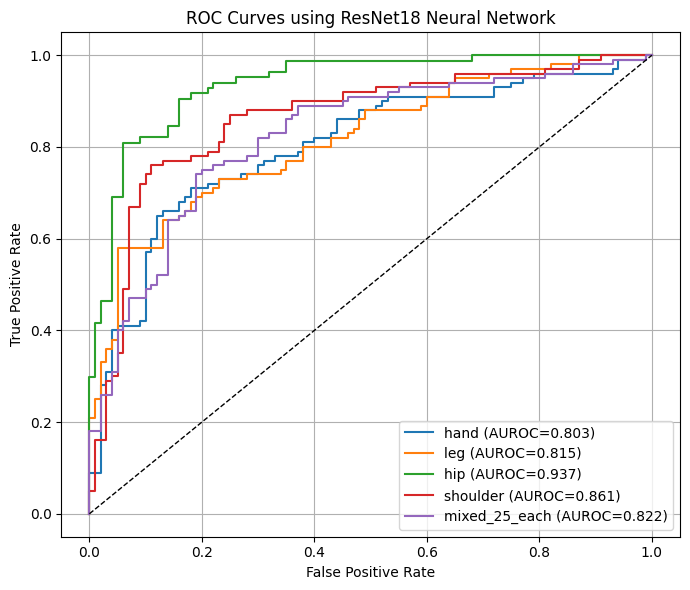

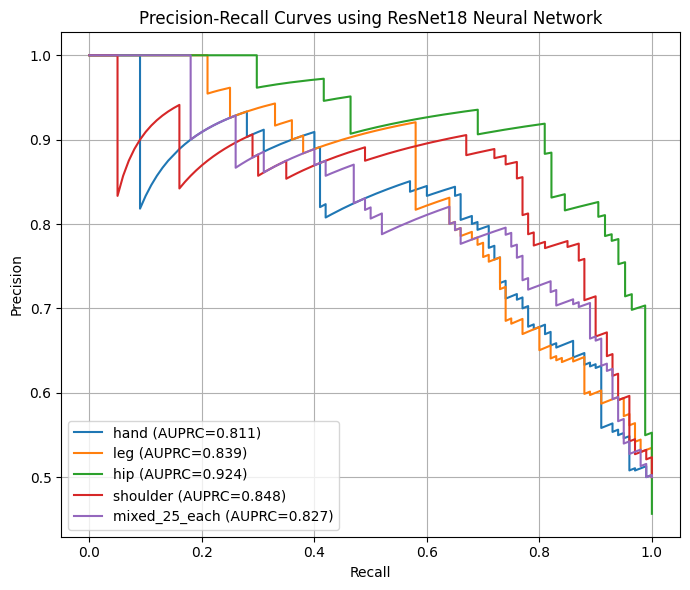

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

if not experiments:
    print("No experiments were run, nothing to plot.")
else:
    # --- ROC curves ---
    plt.figure(figsize=(7, 6))
    for name, info in experiments.items():
        y_true = info["work_df"]["label"].values
        y_score = info["oof"]              # out-of-fold probabilities
        fpr, tpr, _ = roc_curve(y_true, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUROC={info['auroc']:.3f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)  # chance line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves using ResNet18 Neural Network")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Precision–Recall curves ---
    plt.figure(figsize=(7, 6))
    for name, info in experiments.items():
        y_true = info["work_df"]["label"].values
        y_score = info["oof"]
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        plt.plot(recall, precision, label=f"{name} (AUPRC={info['auprc']:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves using ResNet18 Neural Network")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [29]:
# ==== Choose an experiment for Grad-CAM localization ====
# Set this to one of: 'hand', 'leg', 'hip', 'shoulder', 'mixed_25_each' (if it succeeded).

ACTIVE_EXPERIMENT = 'leg'  # <-- change this as needed

if ACTIVE_EXPERIMENT not in experiments:
    raise KeyError(f"ACTIVE_EXPERIMENT '{ACTIVE_EXPERIMENT}' not found in experiments dict.")

active_info = experiments[ACTIVE_EXPERIMENT]
work_df_active = active_info['work_df']

final_model = ResNet18WithPriors(tab_dim=len(prior_cols)).to(DEVICE)
state_dict = torch.load(active_info['model_path'], map_location=DEVICE)
final_model.load_state_dict(state_dict)
final_model.eval()

print(f"Loaded final model for experiment '{ACTIVE_EXPERIMENT}' from {active_info['model_path']}")

Loaded final model for experiment 'leg' from resnet18_priors_512_leg.pt


In [ ]:
# Grad-CAM + localization utilities

class GradCAM:
    def __init__(self, model, target_layer="backbone.layer4"):
        self.model = model.eval()
        self.fmap, self.grad = None, None
        layer = dict(self.model.named_modules())[target_layer]
        layer.register_forward_hook(self._fhook)
        layer.register_full_backward_hook(self._bhook)

    def _fhook(self, m, i, o):
        self.fmap = o.detach()

    def _bhook(self, m, gi, go):
        self.grad = go[0].detach()

    @torch.no_grad()
    def _cam(self):
        w = self.grad.mean(dim=(2, 3), keepdim=True)  # GAP on grads
        cam = (w * self.fmap).sum(1).clamp(min=0)[0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-6)
        return cam

    def __call__(self, xb, tb):
        self.model.zero_grad()
        out = self.model(xb, tb)               # logits
        score = torch.sigmoid(out)
        idx = torch.argmax(score)
        out[idx].backward()
        return self._cam(), float(score[idx].item())


def localize_with_cam_priors(model, row, prior_cols, t_binary=0.4):
    path = row["image_path"]

    # Build eval image
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = pad_to_square(img)
    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), cv2.INTER_AREA)
    img = bg_suppress_and_stretch_numpy(img, t=20)
    img3 = np.stack([img, img, img], axis=-1)
    pil  = Image.fromarray(img3)

    t_eval = transforms.Compose([
        transforms.Resize(TARGET_SIZE),
        transforms.CenterCrop(TARGET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.25]*3),
    ])
    xb = t_eval(pil).unsqueeze(0).to(DEVICE)

    # Prior tensor
    tb_np = row[prior_cols].values.astype("float32")
    tb = torch.tensor(tb_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    cammer = GradCAM(model)
    cam, prob = cammer(xb, tb)

    # 🔧 NEW: resize CAM to full resolution so it matches the image
    cam = cv2.resize(cam, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LINEAR)

    # Threshold CAM → largest blob → circle
    heat = (cam * 255).astype(np.uint8)
    thr = max(1, int(255 * t_binary))
    mask = (heat >= thr).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)

    nlab, labels = cv2.connectedComponents(mask)
    if nlab <= 1:
        center, radius = (TARGET_SIZE // 2, TARGET_SIZE // 2), 8
    else:
        areas = [(labels == i).sum() for i in range(1, nlab)]
        k = np.argmax(areas) + 1
        ys, xs = np.where(labels == k)
        pts = np.stack([xs, ys], axis=1).astype(np.int32)
        (cx, cy), radius = cv2.minEnclosingCircle(pts.reshape(-1, 1, 2))
        center, radius = (int(cx), int(cy)), int(radius)

    base = (img3 / 255.0).copy()

    # Now cam is 512×512 → colormap is also 512×512
    cm = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    cm = cv2.cvtColor(cm, cv2.COLOR_BGR2RGB) / 255.0

    overlay = (0.5 * base + 0.5 * cm).clip(0, 1)
    cv2.circle(overlay, center, radius, (1.0, 1.0, 0.0), 2)

    return overlay, prob


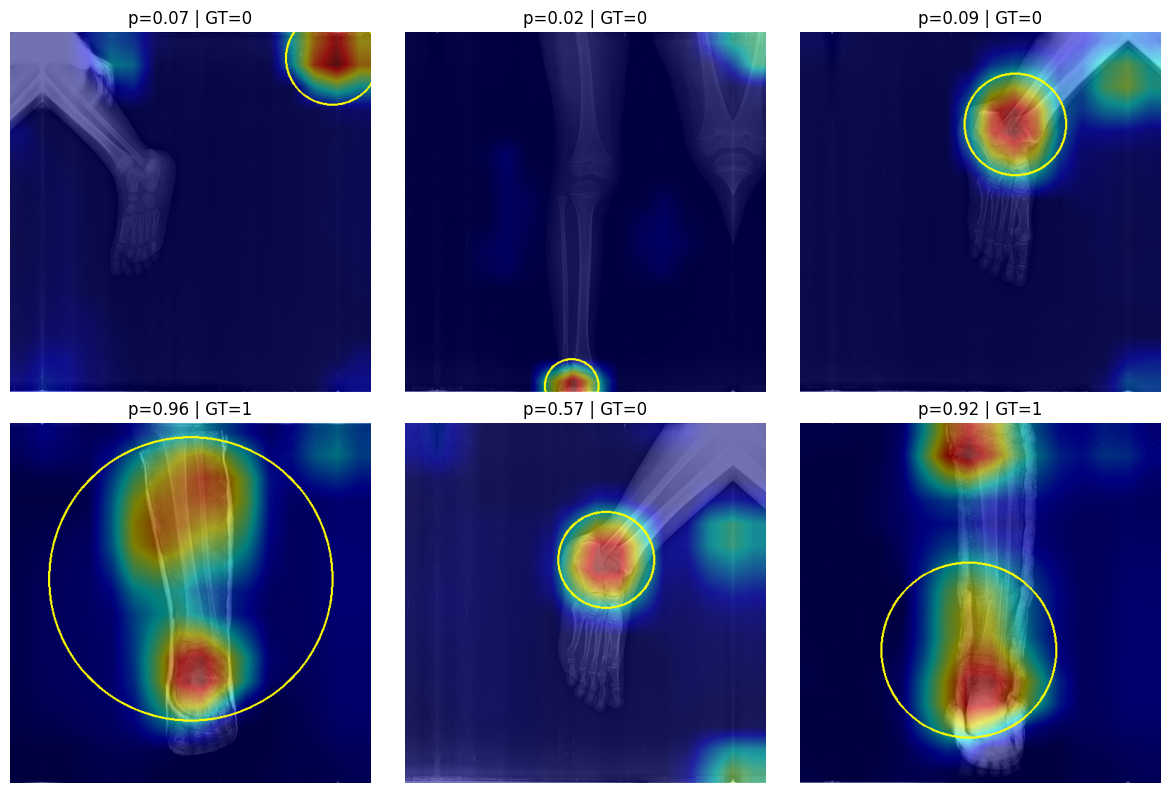

In [32]:
# Example: visualize Grad-CAM localization on a few images from the active experiment

import matplotlib.pyplot as plt

final_model.eval()
idxs = np.random.choice(len(work_df_active), size=min(6, len(work_df_active)), replace=False)
plt.figure(figsize=(12, 8))
for i, k in enumerate(idxs, 1):
    row = work_df_active.iloc[k]
    overlay, prob = localize_with_cam_priors(final_model, row, prior_cols, t_binary=0.4)
    gt = int(row["label"])
    plt.subplot(2, 3, i)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"p={prob:.2f} | GT={gt}")
plt.tight_layout()
plt.show()